# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset: https://www.kaggle.com/datasets/wafaaelhusseini/wine-and-food-pairing-dataset/data?utm_ce=chatgpt.com&select=winefood__pairings.csv

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [1]:
# - Thought Process -
# Import pandas for data handling
import pandas as pd

# Load dataset
df = pd.read_csv('wine_food_pairings.csv')

# Use info() to check datetypes
# Use isnull() to check missing values (Nulls)

print("- Dataset Summary -")
df.info()

# Use shape to confirm the total number of rows and columns
print(df.shape)

- Dataset Summary -
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34933 entries, 0 to 34932
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   wine_type        34933 non-null  object
 1   wine_category    34933 non-null  object
 2   food_item        34933 non-null  object
 3   food_category    34933 non-null  object
 4   cuisine          34933 non-null  object
 5   pairing_quality  34933 non-null  int64 
 6   quality_label    34933 non-null  object
 7   description      34933 non-null  object
dtypes: int64(1), object(7)
memory usage: 2.1+ MB
(34933, 8)


## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [4]:

# Get unique wine category count
print("Total Wine Categories:", df['wine_category'].nunique())

# Get unique wine types count
print("Total unique wine types:", df['wine_type'].nunique())

# Get unique food item count
print("Total unique food items:", df['food_item'].nunique())


# Use aggregation to calculate the variety of wine_type within each category 
# Sort them to see which categories offer the most selection
wine_diversity = df.groupby('wine_category')['wine_type'].agg(['nunique', 'unique']) \
                   .sort_values(by='nunique', ascending=False) \
                   .rename(columns={'nunique': 'Count', 'unique': 'Wine types'})
print("\n- Wine Diversity by Category (Sorted by Variety Count) -")
print(wine_diversity)

Total Wine Categories: 6
Total unique wine types: 29
Total unique food items: 38

- Wine Diversity by Category (Sorted by Variety Count) -
               Count                                         Wine types
wine_category                                                          
Red               12  [Syrah/Shiraz, Grenache, Cabernet Sauvignon, P...
White              9  [Viognier, Albariño, Grüner Veltliner, Rieslin...
Dessert            2                              [Sauternes, Ice Wine]
Fortified          2                                    [Madeira, Port]
Rosé               2                   [Provence Rosé, White Zinfandel]
Sparkling          2                                  [Cava, Champagne]


In [14]:
# Define the specific 5-course menu 
party_menu =['caprese salad', 'cheese platter', 'roast lamb', 'grilled ribeye', 'gazpacho']

# Filter the dataframe for only party menu
party_df = df[df['food_item'].isin(party_menu)]

# Find all rows matching the party menu
print("Rows in party menu:", party_df.shape[0])

# All wine types across all categories, pair with party_menu
# Calculate weighted average 'pairing_quality' score, sort DESC
top_3_for_menu = party_df.groupby(['wine_category', 'wine_type']) \
                 ['pairing_quality'].mean() \
                 .reset_index() \
                 .sort_values(by='pairing_quality', ascending=False) \
                 .head(3)

print("\n- Top 3 high-performers wine types across all categories -")
print(top_3_for_menu.to_string(index=False))

Rows in party menu: 10137

- Top 3 high-performers wine types across all categories -
wine_category    wine_type  pairing_quality
          Red       Merlot         3.191304
          Red Syrah/Shiraz         3.141274
          Red  Tempranillo         3.140845


In [13]:
# Filter for 3 categories
pick_cats = ['Red', 'White', 'Dessert']
filtered_df = df[(df['food_item'].isin(party_menu)) & (df['wine_category'].isin(pick_cats))]

# Find all rows matching the party menu in Red, Whte, Dessert
print("3_catergories_menu_rows:", filtered_df.shape[0])

# Average score and sample size per type
# Aggregate mean and count of pairing_quality per wine type
avg_scores = filtered_df.groupby(['wine_category', 'wine_type']) \
                        ['pairing_quality'].agg(['mean', 'count']) \
                        .reset_index()
                      

# Sort and pick the Top 1 per category
final_winners = avg_scores.sort_values(by='mean', ascending=False) \
                        .groupby('wine_category') \
                        .head(1) \
                        .reset_index(drop=True)

# Rename columns
final_winners = final_winners.rename(columns={'mean': 'pairing_quality', 'count': 'sample_size'})

print("\n- Final wine selections -")
print(final_winners.to_string(index=False))

3_catergories_menu_rows: 8037

- Final wine selections -
wine_category       wine_type  pairing_quality  sample_size
          Red          Merlot         3.191304          345
      Dessert        Ice Wine         3.063401          347
        White Sauvignon Blanc         3.049536          323


In [7]:
# Min, Mean, Max sample size (each wine type pairs with party_menu)
menu_winetype_sample = filtered_df['wine_type'].value_counts()

print(menu_winetype_sample.describe()[['min','mean', 'max']])

# The sample sizes for 'Merlot, Ice Wine, Sauvignon Blanc' fall within the optimal range.
# These consistent counts ensure that our top picks are backed by high-integrity, reliable data.

min     323.000000
mean    349.434783
max     377.000000
Name: count, dtype: float64


## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

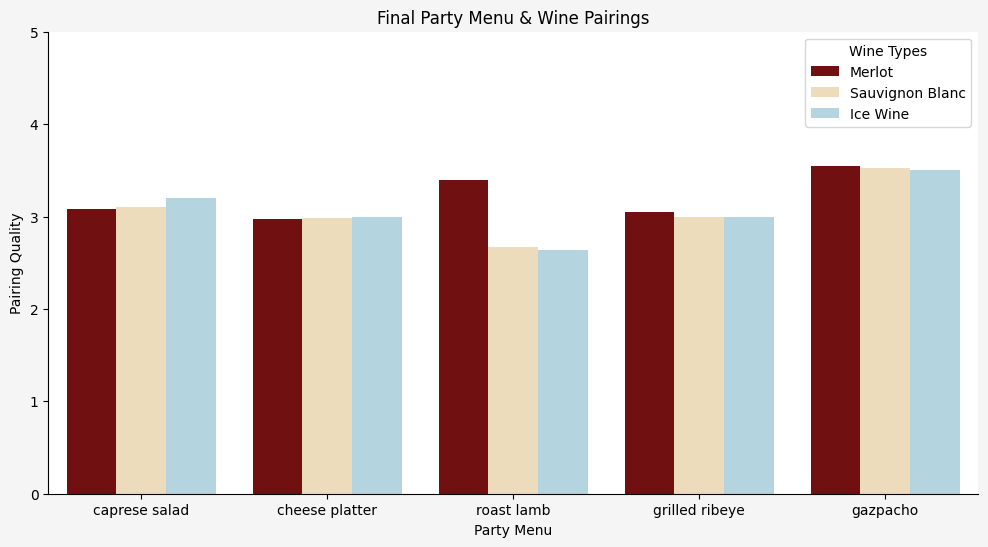

In [ ]:
# Import seaborn/matplotlib for visualization
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('wine_food_pairings.csv')

# Define the 5-course menu and the top performing wine types
party_menu =['caprese salad', 'cheese platter', 'roast lamb', 'grilled ribeye', 'gazpacho']
winners = ['Merlot', 'Sauvignon Blanc', 'Ice Wine']

# Filter for food items & wine types, pivot to ensure a complete 5x3 matrix
plot_df = df[df['food_item'].isin(party_menu) & df['wine_type'].isin(winners)].copy()
pivot_df = plot_df.pivot_table(index='food_item', columns='wine_type', values='pairing_quality', aggfunc='mean')
pivot_df = pivot_df.reindex(index=party_menu, columns=winners).fillna(0)
plot_ready = pivot_df.reset_index().melt(
    id_vars='food_item', 
    var_name='wine_type', 
    value_name='pairing_quality'
)

# Visual mappling: 3 color palette
color_map = {
    'Merlot': 'maroon',
    'Sauvignon Blanc': 'wheat',
    'Ice Wine': 'lightblue'
}

# Neutral background for better readability
# Plot the bar chart to visualize pairing trends
plt.figure(figsize=(12, 6), facecolor='whitesmoke')
ax = sns.barplot(data=plot_ready, x='food_item', y='pairing_quality', hue='wine_type', palette=color_map)

# Axis scales matching pairing_quality
plt.title('Final Party Menu & Wine Pairings')
plt.ylim(0, 5)

# Moved the legend, ensure all bar data remains visible.
plt.legend(title='Wine Types', bbox_to_anchor=(1, 1))

plt.ylabel('Pairing Quality')
plt.xlabel('Party Menu')

# Removed top and right spines for clean present
sns.despine()
plt.show()

## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 
   
What surprised me most was the Dominance of Red Wines. If I simply selected the three wines with the highest average scores across the entire 5-course menu, all three winners would be red wines (Merlot, Syrah/Shiraz, and Tempranillo). This suggests that the chosen menu items have a strong overall affinity for the bold flavor of reds. 

However, to align with my primary analytical goal from Checkpoint 1， which was to ensure a more balanced and diverse wine selection, I selected the top-performing wine from each distinct category (Red, White, and Dessert), which resulted in the final selection of Merlot, Sauvignon Blanc, and Ice Wine.

2. Do you have any concerns about your dataset? 
   
My main concern is that because red wines show such a strong performance trend, the sample sizes for white and dessert wines might be smaller. I need to ensure that the "category winners" like Sauvignon Blanc and Ice Wine are backed by enough data points to be statistically meaningful.

3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 

Case sensitivity and whitespace: I noticed inconsistent capitalization in food_item (e.g., 'Indian Vindaloo' vs. 'Thai curry'). I need to apply a universal .str.lower() and .str.strip() to both food_item and wine_type columns to prevent omitting data in my average pairing quality calculation. This ensures that variations in casing or hidden trailing spaces don't split the same item into multiple categories.

Special character standardization: Entries like 'Riesling(dry)' and 'Syrah/Shiraz' contain parentheses and slashes. I need to investigate if these varietals are recorded under multiple formats (for example,'Syrah' vs. 'Syrah/Shiraz') and consolidate them to ensure accurate pivot_table aggregations.
